# Questão 1 · Material complementar: estratégias alternativas e robustez do resultado

**Projeto de Aprendizagem de Máquina 2026-2** · Prof. Francisco de A. T. de Carvalho · CIn/UFPE

---

Este notebook complementa o notebook principal
[`questao1_double_kmeans.ipynb`](questao1_double_kmeans.ipynb). **Ele não substitui o resultado
oficial da Questão 1**, apenas testa a sua robustez. Deve ser executado **depois** do notebook
principal, cujas saídas (`results/tabela_KH.csv` e `results/particao_objetos_Kstar.csv`) ele usa
como referência.

## Pergunta investigada

No notebook principal, o protocolo do enunciado seleciona $(K^*, H^*) = (2,2)$, com silhueta
0,660, uma partição de objetos degenerada (4567 × 34 e-mails) e índice de Rand corrigido (ARI)
de −0,005 contra a partição *a priori*. A causa identificada foi a interação entre a
padronização *z-score* e variáveis muito esparsas associadas ao doador da base.

Daí decorre uma pergunta natural, que este notebook responde empiricamente:

> **Outra escolha de pré-processamento "consertaria" o resultado?** Isto é, existe um
> pré-processamento razoável sob o qual o critério $K^* = \arg\max_{(K,H)} Sil(K,H)$ selecione uma
> partição que recupere a distinção spam / não-spam?

Uma segunda pergunta, de natureza diferente, também é examinada:

> **O resultado oficial depende das sementes aleatórias?** O melhor de 100 execuções é o mesmo
> se o protocolo for repetido com outras inicializações?

## Cuidados metodológicos

1. **O rótulo *a priori* é usado apenas para avaliar, nunca para escolher.** Selecionar o
   pré-processamento pelo ARI significaria usar a variável resposta para ajustar um método não
   supervisionado, um vazamento de informação que invalidaria a Questão 1. Por isso, as
   estratégias são comparadas lado a lado e **nenhuma delas é promovida a resultado oficial**.
2. **Comparação pareada.** Todas as estratégias usam exatamente o mesmo protocolo do enunciado
   (9 pares $(K,H)$ × 100 execuções, retenção do menor $W$, $K^*$ pela silhueta), a mesma
   implementação e **as mesmas sementes**. A única diferença entre elas é o pré-processamento.
3. **A silhueta é calculada no mesmo espaço em que o agrupamento foi feito**, como no notebook
   principal.

## Roteiro

| Seção | Conteúdo |
|---|---|
| 1 | Configuração, dados e referências do notebook principal |
| 2 | Implementação (idêntica à do notebook principal) |
| 3 | Estratégias de pré-processamento avaliadas e diagnóstico prévio |
| 4 | Execução do protocolo completo para cada estratégia e verificação de reprodutibilidade |
| 5 | Resultados: o que muda e o que não muda |
| 6 | A silhueta do rótulo verdadeiro em cada espaço |
| 7 | Estabilidade do protocolo oficial frente às sementes |
| 8 | Conclusões |


---
## 1. Configuração, dados e referências

O protocolo completo é executado para 8 estratégias e, na Seção 7, mais duas vezes para a
estratégia oficial: são 90 combinações (estratégia × par) e **9.000 execuções** do Double
K-means. As combinações são independentes entre si e são distribuídas entre os núcleos da
máquina com `joblib`. Como cada execução tem semente própria, o resultado não depende da ordem
nem do número de processos.

In [2]:
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import QuantileTransformer, StandardScaler

warnings.filterwarnings("ignore")

# --- Protocolo: identico ao do notebook principal ------------------------------
MASTER_SEED = 42
N_INIT = 100
MAX_ITER = 100
K_VALUES = (2, 3, 4)
PARES = [(K, H) for K in K_VALUES for H in range(1, K + 1)]
TOL = 1e-4          # execucao "atinge o melhor minimo" se W <= W* (1 + 0,01%)
N_JOBS = -1         # todos os nucleos disponiveis

def semente_do_par(K, H, bloco=0):
    # Mesma regra do notebook principal; 'bloco' desloca todas as sementes (Secao 7).
    return MASTER_SEED * 1000 + K * 10 + H + bloco

# --- Apresentacao (mesma paleta do notebook principal) ------------------------
mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titlesize": 11, "axes.titleweight": "bold",
    "font.size": 9.5, "legend.frameon": False,
})
C_PRIMARY, C_SECONDARY, C_TERTIARY = "#33538f", "#c2703d", "#4e8a6b"
C_MUTED, C_ALERT = "#9a958a", "#a8433a"
K_COLORS = {2: C_PRIMARY, 3: C_SECONDARY, 4: C_TERTIARY}

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)
print("Ambiente configurado.")
print(f"numpy {np.__version__} | pandas {pd.__version__}")

Ambiente configurado.
numpy 2.5.3 | pandas 3.0.6


In [3]:
def find_data_dir() -> Path:
    for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        if (candidate / "spambase.data").exists():
            return candidate
    raise FileNotFoundError("spambase.data nao encontrado a partir de " + str(Path.cwd()))

DATA_DIR = find_data_dir()
RESULTS_Q1 = DATA_DIR / "q1" / "results"
OUT_DIR = RESULTS_Q1 / "estrategias"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ATTRIBUTE_NAMES = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d",
    "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet",
    "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will",
    "word_freq_people", "word_freq_report", "word_freq_addresses", "word_freq_free",
    "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit",
    "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money",
    "word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650",
    "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857",
    "word_freq_data", "word_freq_415", "word_freq_85", "word_freq_technology",
    "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct",
    "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project",
    "word_freq_re", "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_;", "char_freq_(", "char_freq_[", "char_freq_!", "char_freq_$",
    "char_freq_#", "capital_run_length_average", "capital_run_length_longest",
    "capital_run_length_total",
]
df = pd.read_csv(DATA_DIR / "spambase.data", header=None, names=ATTRIBUTE_NAMES + ["spam"])
X_raw = df[ATTRIBUTE_NAMES].to_numpy(dtype=np.float64)
y = df["spam"].to_numpy(dtype=np.int64)
N, P = X_raw.shape
IDX_FREQ = [j for j, nome in enumerate(ATTRIBUTE_NAMES) if not nome.startswith("capital_run")]
IDX_CAP = [j for j, nome in enumerate(ATTRIBUTE_NAMES) if nome.startswith("capital_run")]

# --- Referencias produzidas pelo notebook principal ----------------------------
tabela_oficial = pd.read_csv(RESULTS_Q1 / "tabela_KH.csv")
particao_oficial = pd.read_csv(RESULTS_Q1 / "particao_objetos_Kstar.csv")
assert np.array_equal(particao_oficial["spam_a_priori"].to_numpy(), y)
u_oficial = particao_oficial["cluster_double_kmeans"].to_numpy()
franja = u_oficial == np.argmin(np.bincount(u_oficial))    # os e-mails do cluster minoritario

print(f"N = {N} objetos, P = {P} variaveis ({len(IDX_FREQ)} de frequencia, {len(IDX_CAP)} capital_run)")
print(f"Cluster minoritario da solucao oficial: {franja.sum()} e-mails ({franja.mean():.2%} da base)")
print("Saidas em:", OUT_DIR.relative_to(DATA_DIR))

N = 4601 objetos, P = 57 variaveis (54 de frequencia, 3 capital_run)
Cluster minoritario da solucao oficial: 34 e-mails (0.74% da base)
Saidas em: q1/results/estrategias


---
## 2. Implementação

O código abaixo é **idêntico** ao da Seção 3 do notebook principal (mesmas funções, mesma
inicialização, mesmo critério de parada). Ele é repetido aqui para que este notebook seja
autocontido. A Seção 4 verifica que ele reproduz exatamente a tabela oficial.

In [4]:
def _init_labels(n: int, n_clusters: int, rng: np.random.Generator) -> np.ndarray:
    # Particao inicial aleatoria garantindo que nenhum grupo nasca vazio.
    labels = np.empty(n, dtype=np.int64)
    order = rng.permutation(n)
    labels[order[:n_clusters]] = np.arange(n_clusters)
    if n > n_clusters:
        labels[order[n_clusters:]] = rng.integers(0, n_clusters, size=n - n_clusters)
    return labels


def _prototypes(X, u, v, K, H, prev_G=None):
    # PASSO 1: g_kh = soma dos x_ij no bloco kh / (n_k * n_h)
    U = np.eye(K, dtype=X.dtype)[u]          # N x K (matriz indicadora)
    V = np.eye(H, dtype=X.dtype)[v]          # P x H (matriz indicadora)
    block_sum = U.T @ X @ V                   # K x H, soma de cada bloco
    nk, nh = U.sum(axis=0), V.sum(axis=0)

    G = block_sum / np.outer(np.where(nk == 0, 1.0, nk), np.where(nh == 0, 1.0, nh))

    # Blocos cujo grupo ficou vazio nao tem media definida: preserva-se o
    # prototipo anterior para nao colapsar o grupo em zero.
    if prev_G is not None:
        if (nk == 0).any():
            G[nk == 0, :] = prev_G[nk == 0, :]
        if (nh == 0).any():
            G[:, nh == 0] = prev_G[:, nh == 0]
    return G, nk, nh


def _assign_objects(X, G, v):
    # PASSO 2: reatribui cada objeto ao grupo k mais proximo (G, V fixos)
    Ghat = G[:, v]                                        # K x P
    dist = (np.sum(X ** 2, axis=1, keepdims=True)
            - 2.0 * X @ Ghat.T
            + np.sum(Ghat ** 2, axis=1, keepdims=True).T)  # N x K
    return np.argmin(dist, axis=1)


def _assign_variables(X, G, u):
    # PASSO 3: reatribui cada variavel ao grupo h mais proximo (G, U fixos)
    Ghat = G[u, :]                                        # N x H
    dist = (np.sum(X ** 2, axis=0, keepdims=True).T
            - 2.0 * X.T @ Ghat
            + np.sum(Ghat ** 2, axis=0, keepdims=True))    # P x H
    return np.argmin(dist, axis=1)


def _objective(X, G, u, v) -> float:
    # W(G, U, V): soma dos quadrados dos residuos objeto-variavel-bloco
    return float(np.sum((X - G[u][:, v]) ** 2))


@dataclass
class DoubleKMeansResult:
    K: int
    H: int
    G: np.ndarray                    # K x H, matriz de prototipos
    u: np.ndarray                    # N, rotulos dos objetos
    v: np.ndarray                    # P, rotulos das variaveis
    objective: float                 # W final
    objective_history: list = field(default_factory=list)
    n_iter: int = 0
    converged: bool = False
    random_state: int = None


class DoubleKMeans:
    # Double K-means para dados vetoriais (co-clustering exclusivo).

    def __init__(self, n_row_clusters, n_col_clusters, max_iter=MAX_ITER, random_state=None):
        self.K = n_row_clusters
        self.H = n_col_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X) -> DoubleKMeansResult:
        X = np.asarray(X, dtype=np.float64)
        N, P = X.shape
        K, H = self.K, self.H
        rng = np.random.default_rng(self.random_state)

        # --- Inicializacao: (G0, U0, V0)
        u = _init_labels(N, K, rng)
        v = _init_labels(P, H, rng)
        G, _, _ = _prototypes(X, u, v, K, H)
        history = [_objective(X, G, u, v)]

        converged, it = False, 0
        for it in range(1, self.max_iter + 1):
            G, _, _ = _prototypes(X, u, v, K, H, prev_G=G)   # Passo 1
            u_new = _assign_objects(X, G, v)                  # Passo 2
            v_new = _assign_variables(X, G, u_new)             # Passo 3

            history.append(_objective(X, G, u_new, v_new))
            sem_transferencia = np.array_equal(u_new, u) and np.array_equal(v_new, v)
            u, v = u_new, v_new
            if sem_transferencia:                              # criterio de parada
                converged = True
                break

        G, _, _ = _prototypes(X, u, v, K, H, prev_G=G)
        final = _objective(X, G, u, v)
        history.append(final)

        return DoubleKMeansResult(K=K, H=H, G=G, u=u, v=v, objective=final,
                                  objective_history=history, n_iter=it,
                                  converged=converged, random_state=self.random_state)


def run_many(X, K, H, n_init=N_INIT, seed=0):
    # Executa n_init vezes com inicializacoes distintas (sementes seed, seed+1, ...) e devolve
    # (melhor resultado segundo W, W de cada execucao, indicador de convergencia de cada execucao).
    melhor, todos_W, todos_conv = None, [], []
    for i in range(n_init):
        res = DoubleKMeans(K, H, random_state=seed + i).fit(X)
        todos_W.append(res.objective)
        todos_conv.append(res.converged)
        if melhor is None or res.objective < melhor.objective:
            melhor = res
    return melhor, np.array(todos_W), np.array(todos_conv)

print("Double K-means implementado (identico ao notebook principal).")

Double K-means implementado (identico ao notebook principal).


---
## 3. Estratégias de pré-processamento avaliadas

As oito estratégias abaixo cobrem as famílias usuais de preparação de dados para métodos
baseados em distância euclidiana. **Todas são justificáveis antes de observar qualquer resultado**,
e nenhuma usa o rótulo.

| Código | Estratégia | Motivação |
|---|---|---|
| **E0** | *z-score* (**oficial**) | Referência: pipeline do notebook principal. Iguala a variância de todas as variáveis. |
| **E1** | Dados brutos | Controle: nenhum ajuste de escala. |
| **E2** | Min-max em $[0,1]$ | Normalização usual por amplitude; limita o intervalo de cada variável, mas não a assimetria. |
| **E3** | *z-score* recortado em $\pm 3$ | Ataca diretamente os valores extremos (winsorização em 3 desvios-padrão). |
| **E4** | $\log(1+x)$ + *z-score* | Comprime a cauda direita antes de padronizar; prática padrão para frequências e contagens. |
| **E5** | $\log(1+x)$ + min-max | Idem, com normalização por amplitude. |
| **E6** | Transformação por quantis (normal) | Elimina a assimetria de forma não paramétrica: cada marginal passa a ter distribuição aproximadamente normal. Como há muitos zeros, todos os zeros de uma variável recebem o mesmo valor. |
| **E7** | Binarização | Para as 54 variáveis de frequência, só a presença ou ausência do termo; para as 3 `capital_run_length_*`, $\log(1+x)$ + min-max. |


In [5]:
def zscore(A):
    return StandardScaler().fit_transform(A)

def minmax(A):
    amplitude = A.max(axis=0) - A.min(axis=0)
    return (A - A.min(axis=0)) / np.where(amplitude == 0, 1.0, amplitude)

X_bin = np.empty_like(X_raw)
X_bin[:, IDX_FREQ] = (X_raw[:, IDX_FREQ] > 0).astype(np.float64)
X_bin[:, IDX_CAP] = minmax(np.log1p(X_raw[:, IDX_CAP]))

ESTRATEGIAS = {
    "E0": ("z-score (oficial)",         zscore(X_raw)),
    "E1": ("dados brutos",              X_raw.copy()),
    "E2": ("min-max",                   minmax(X_raw)),
    "E3": ("z-score recortado em ±3",   np.clip(zscore(X_raw), -3.0, 3.0)),
    "E4": ("log(1+x) + z-score",        zscore(np.log1p(X_raw))),
    "E5": ("log(1+x) + min-max",        minmax(np.log1p(X_raw))),
    "E6": ("quantis → normal",          QuantileTransformer(n_quantiles=1000,
                                            output_distribution="normal",
                                            random_state=MASTER_SEED).fit_transform(X_raw)),
    "E7": ("binarização",               X_bin),
}
NOMES = {cod: f"{cod} · {nome}" for cod, (nome, _) in ESTRATEGIAS.items()}
DADOS = {cod: Z for cod, (_, Z) in ESTRATEGIAS.items()}
print("Estrategias:", ", ".join(NOMES.values()))

Estrategias: E0 · z-score (oficial), E1 · dados brutos, E2 · min-max, E3 · z-score recortado em ±3, E4 · log(1+x) + z-score, E5 · log(1+x) + min-max, E6 · quantis → normal, E7 · binarização


### 3.1 Diagnóstico prévio: quanto da dispersão está concentrado em poucos e-mails?

O Double K-means minimiza uma soma de quadrados. Se poucos objetos concentram uma fração
desproporcional da **soma de quadrados total** $\sum_i \|x_i - \bar{x}\|^2$, isolá-los em um
grupo próprio reduz muito $W$, e o algoritmo tende a fazê-lo. Esse diagnóstico **não usa o
rótulo** e antecipa quais estratégias devem produzir clusters degenerados.

Medimos duas quantidades em cada espaço:
- a participação dos **34 e-mails do cluster minoritário da solução oficial** (0,74% da base);
- a participação do **1% de e-mails mais afastados do centro** naquele espaço.

Sob uma dispersão homogênea, ambas estariam próximas de 0,74% e 1%, respectivamente.

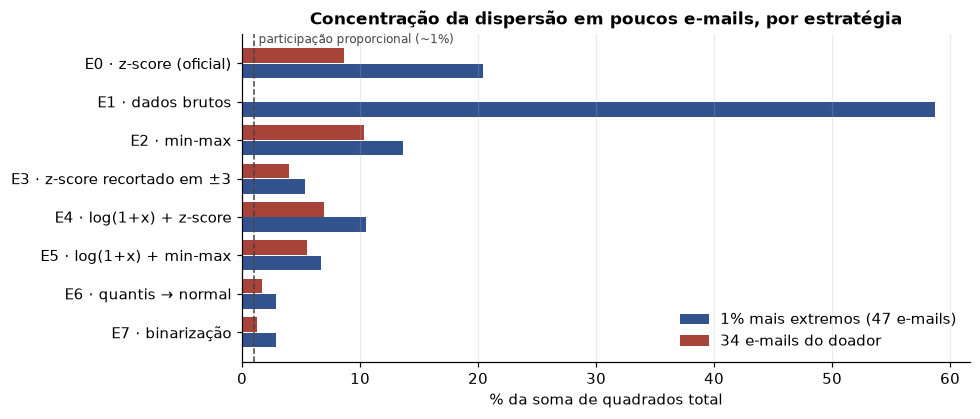

,participacao_34_emails_doador_%,participacao_1%_mais_extremos_%
estrategia,,
E0 · z-score (oficial),8.68,20.41
E1 · dados brutos,0.11,58.72
E2 · min-max,10.33,13.64
E3 · z-score recortado em ±3,3.96,5.35
E4 · log(1+x) + z-score,6.91,10.49
E5 · log(1+x) + min-max,5.53,6.73
E6 · quantis → normal,1.71,2.86
E7 · binarização,1.29,2.89


In [6]:
n_top = int(np.ceil(0.01 * N))
diag_prev = []
for cod, Z in DADOS.items():
    ss = ((Z - Z.mean(axis=0)) ** 2).sum(axis=1)
    diag_prev.append({
        "estrategia": NOMES[cod],
        "participacao_34_emails_doador_%": 100 * ss[franja].sum() / ss.sum(),
        "participacao_1%_mais_extremos_%": 100 * np.sort(ss)[::-1][:n_top].sum() / ss.sum(),
    })
diag_prev = pd.DataFrame(diag_prev).set_index("estrategia")

fig, ax = plt.subplots(figsize=(9, 3.9))
pos = np.arange(len(diag_prev))
ax.barh(pos + 0.2, diag_prev["participacao_1%_mais_extremos_%"], height=0.38, color=C_PRIMARY,
        label=f"1% mais extremos ({n_top} e-mails)")
ax.barh(pos - 0.2, diag_prev["participacao_34_emails_doador_%"], height=0.38, color=C_ALERT,
        label=f"{franja.sum()} e-mails do doador")
ax.axvline(1.0, color="#444444", linestyle="--", linewidth=1)
ax.text(1.4, -0.62, "participação proporcional (~1%)", fontsize=8, color="#444444", va="center")
ax.set_yticks(pos)
ax.set_yticklabels(diag_prev.index)
ax.invert_yaxis()
ax.set_xlabel("% da soma de quadrados total")
ax.set_title("Concentração da dispersão em poucos e-mails, por estratégia")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "concentracao_dispersao.png", dpi=150, bbox_inches="tight")
plt.show()

diag_prev.round(2)

> **Leitura.** No espaço *z-score* oficial (E0), os 34 e-mails do doador, 0,74% da base,
> concentram **8,7%** da soma de quadrados total, cerca de 12 vezes a sua participação
> proporcional, e o 1% de e-mails mais extremos concentra 20%. Isolar esse grupo é, portanto,
> uma forma muito eficiente de reduzir $W$. A normalização min-max (E2) e o $\log(1+x)$ seguido
> de *z-score* (E4) mantêm concentrações da mesma ordem. O recorte em $\pm 3$ (E3), o
> $\log(1+x)$ com min-max (E5), a transformação por quantis (E6) e a binarização (E7) reduzem-na
> substancialmente; nas duas últimas, o 1% mais extremo responde por menos de 3% da dispersão,
> praticamente a sua participação proporcional.
>
> Nos dados brutos (E1) a concentração é a maior de todas (59%), mas por outro motivo: ela vem
> das variáveis `capital_run_length_*`, cuja escala domina a distância, e não do vocabulário do
> doador, que ali responde por apenas 0,1%.
>
> O diagnóstico prevê que E3, E5, E6 e E7 deixem de produzir o cluster degenerado. A pergunta
> que importa para a Questão 1, porém, é outra: **eliminado o artefato, a silhueta passa a
> escolher uma partição alinhada ao rótulo?**

---
## 4. Execução do protocolo para cada estratégia

Para cada estratégia e cada par $(K,H)$: 100 execuções com as sementes do protocolo oficial,
retenção do menor $W$, silhueta e ARI da partição retida. As mesmas 900 execuções da estratégia
E0 são repetidas com dois outros blocos de sementes, para a Seção 7.

In [7]:
BLOCOS_SEMENTES = (0, 10_000, 20_000)   # bloco 0 = sementes do protocolo oficial

def executar(Z, cod, K, H, bloco):
    # Protocolo do enunciado para um par (K, H) em um espaco Z.
    melhor, todos_W, todos_conv = run_many(Z, K, H, n_init=N_INIT, seed=semente_do_par(K, H, bloco))
    return {
        "estrategia": cod, "K": K, "H": H, "bloco": bloco,
        "W_melhor": melhor.objective, "u": melhor.u, "v": melhor.v, "G": melhor.G,
        "todos_W": todos_W, "execucoes_convergidas": int(todos_conv.sum()),
        "Silhueta": silhouette_score(Z, melhor.u) if len(np.unique(melhor.u)) > 1 else np.nan,
    }

tarefas = [(cod, K, H, 0) for cod in DADOS for (K, H) in PARES]
tarefas += [("E0", K, H, b) for b in BLOCOS_SEMENTES[1:] for (K, H) in PARES]

t0 = time.time()
saidas = Parallel(n_jobs=N_JOBS)(delayed(executar)(DADOS[cod], cod, K, H, b)
                                 for cod, K, H, b in tarefas)
R = {(s["estrategia"], s["K"], s["H"], s["bloco"]): s for s in saidas}
print(f"{len(tarefas)} combinacoes (estrategia x par), {len(tarefas) * N_INIT} execucoes, "
      f"em {time.time() - t0:.0f}s")

90 combinacoes (estrategia x par), 9000 execucoes, em 216s


In [8]:
def linha_resultado(s):
    tam = np.bincount(s["u"], minlength=s["K"])
    return {
        "estrategia": s["estrategia"], "K": s["K"], "H": s["H"],
        "W_melhor": s["W_melhor"],
        "execucoes_no_otimo_%": 100 * np.mean(s["todos_W"] <= s["W_melhor"] * (1 + TOL)),
        "execucoes_convergidas": s["execucoes_convergidas"],
        "Silhueta": s["Silhueta"],
        "ARI": adjusted_rand_score(y, s["u"]),
        "menor_cluster": int(tam.min()),
        "tamanhos": " / ".join(str(n) for n in sorted(tam)),
        "grupos_variaveis": " / ".join(str(n) for n in sorted(np.bincount(s["v"], minlength=s["H"]))),
    }

grade = pd.DataFrame([linha_resultado(R[(cod, K, H, 0)]) for cod in DADOS for (K, H) in PARES])

# --- Verificacao: E0 deve reproduzir exatamente a tabela oficial do notebook principal
e0 = grade[grade["estrategia"] == "E0"].reset_index(drop=True)
dif_W = np.abs(e0["W_melhor"].to_numpy() - tabela_oficial["W_melhor"].to_numpy()).max()
dif_sil = np.abs(e0["Silhueta"].to_numpy() - tabela_oficial["Silhueta"].to_numpy()).max()
dif_ari = np.abs(e0["ARI"].to_numpy() - tabela_oficial["ARI"].to_numpy()).max()
ari_particao = adjusted_rand_score(u_oficial, R[("E0", 2, 2, 0)]["u"])
print("Verificacao de reprodutibilidade (E0 x notebook principal):")
print(f"  maior diferenca em W*       : {dif_W:.2e}")
print(f"  maior diferenca na silhueta : {dif_sil:.2e}")
print(f"  maior diferenca no ARI      : {dif_ari:.2e}")
print(f"  ARI entre a particao (2,2) daqui e a particao oficial: {ari_particao:.4f}")
assert dif_W < 1e-6 and dif_sil < 1e-9 and dif_ari < 1e-9 and ari_particao == 1.0
print("  -> reproducao exata.")

Verificacao de reprodutibilidade (E0 x notebook principal):
  maior diferenca em W*       : 2.91e-11
  maior diferenca na silhueta : 5.55e-17
  maior diferenca no ARI      : 7.98e-17
  ARI entre a particao (2,2) daqui e a particao oficial: 1.0000
  -> reproducao exata.


---
## 5. Resultados: o que muda e o que não muda

### 5.1 Tabela completa

Os 72 resultados (8 estratégias × 9 pares), cada um o melhor de 100 execuções.

In [9]:
exibir = grade.copy()
exibir.insert(0, "descricao", exibir["estrategia"].map(lambda c: ESTRATEGIAS[c][0]))
exibir.round({"W_melhor": 2, "execucoes_no_otimo_%": 0, "Silhueta": 4, "ARI": 4})

,descricao,estrategia,K,H,W_melhor,execucoes_no_otimo_%,execucoes_convergidas,Silhueta,ARI,menor_cluster,tamanhos,grupos_variaveis
0,z-score (oficial),E0,2,1,2.565138e+05,100.0,100,0.2961,0.0686,1018,1018 / 3583,57
1,z-score (oficial),E0,2,2,2.444867e+05,7.0,100,0.6596,-0.0049,34,34 / 4567,11 / 46
2,z-score (oficial),E0,3,1,2.544140e+05,100.0,100,0.2515,0.0784,32,32 / 1187 / 3382,57
3,z-score (oficial),E0,3,2,2.393737e+05,1.0,100,0.2454,0.1984,34,34 / 1097 / 3470,11 / 46
4,z-score (oficial),E0,3,3,2.345859e+05,20.0,100,0.1409,0.3854,34,34 / 1194 / 3373,11 / 22 / 24
5,z-score (oficial),E0,4,1,2.532787e+05,100.0,100,0.0484,0.0916,22,22 / 697 / 1640 / 2242,57
6,z-score (oficial),E0,4,2,2.333587e+05,25.0,99,0.2428,0.1493,24,24 / 253 / 1049 / 3275,12 / 45
7,z-score (oficial),E0,4,3,2.285164e+05,22.0,100,0.1620,0.2744,24,24 / 241 / 1080 / 3256,11 / 22 / 24
8,z-score (oficial),E0,4,4,2.272616e+05,1.0,100,0.1576,0.2451,29,29 / 400 / 1074 / 3098,5 / 9 / 18 / 25
9,dados brutos,E1,2,1,2.219683e+09,100.0,100,0.8444,0.0422,238,238 / 4363,57


### 5.2 Síntese por estratégia

Para cada estratégia, a tabela abaixo aplica o critério do enunciado ($K^* = \arg\max Sil$) e o
compara com o par de maior ARI da grade. A coluna **posição pela silhueta** indica em que lugar
o par de maior ARI ficaria no ranking de silhueta (1º = seria o escolhido). A coluna
$\rho$ é a correlação de Spearman entre silhueta e ARI nos 9 pares da estratégia.

In [10]:
silhueta_rotulo = {cod: silhouette_score(Z, y) for cod, Z in DADOS.items()}

sintese = []
for cod in DADOS:
    g = grade[grade["estrategia"] == cod].reset_index(drop=True)
    sel = g.loc[g["Silhueta"].idxmax()]
    top = g.loc[g["ARI"].idxmax()]
    sintese.append({
        "estrategia": NOMES[cod],
        "(K*,H*)": f"({sel.K},{sel.H})",
        "Sil_em_K*": sel.Silhueta,
        "ARI_em_K*": sel.ARI,
        "tamanhos_em_K*": sel.tamanhos,
        "menor_cluster_em_K*_%": 100 * sel.menor_cluster / N,
        "maior_ARI_da_grade": top.ARI,
        "par_do_maior_ARI": f"({top.K},{top.H})",
        "posicao_pela_silhueta": f"{int((g['Silhueta'] > top.Silhueta).sum()) + 1}º de {len(g)}",
        "menor_cluster_da_grade": int(g["menor_cluster"].min()),
        "rho_Spearman(Sil,ARI)": spearmanr(g["Silhueta"], g["ARI"]).statistic,
    })
sintese = pd.DataFrame(sintese).set_index("estrategia")
sintese.round(3)

,"(K*,H*)",Sil_em_K*,ARI_em_K*,tamanhos_em_K*,menor_cluster_em_K*_%,maior_ARI_da_grade,par_do_maior_ARI,posicao_pela_silhueta,menor_cluster_da_grade,"rho_Spearman(Sil,ARI)"
estrategia,,,,,,,,,,
E0 · z-score (oficial),"(2,2)",0.660,-0.005,34 / 4567,0.739,0.385,"(3,3)",8º de 9,22,-0.717
E1 · dados brutos,"(2,1)",0.844,0.042,238 / 4363,5.173,0.100,"(4,2)",9º de 9,5,-0.933
E2 · min-max,"(2,1)",0.223,0.095,1139 / 3462,24.755,0.204,"(3,3)",5º de 9,20,-0.050
E3 · z-score recortado em ±3,"(2,1)",0.190,0.142,1140 / 3461,24.777,0.461,"(2,2)",4º de 9,174,0.467
E4 · log(1+x) + z-score,"(2,1)",0.189,0.120,1203 / 3398,26.146,0.536,"(2,2)",6º de 9,33,0.167
E5 · log(1+x) + min-max,"(3,3)",0.129,0.391,265 / 1717 / 2619,5.760,0.391,"(3,3)",1º de 9,190,0.767
E6 · quantis → normal,"(3,3)",0.183,0.276,557 / 1252 / 2792,12.106,0.276,"(3,3)",1º de 9,230,0.800
E7 · binarização,"(2,1)",0.192,0.115,1646 / 2955,35.775,0.229,"(4,2)",3º de 9,229,0.550


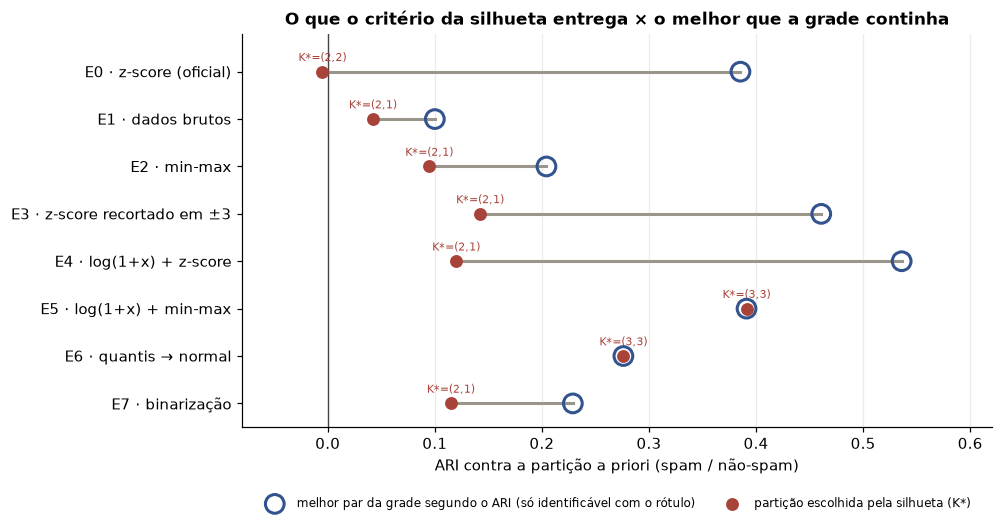

In [11]:
fig, ax = plt.subplots(figsize=(9.2, 4.9))
pos = np.arange(len(sintese))
for i, (nome, r) in enumerate(sintese.iterrows()):
    ax.plot([r["ARI_em_K*"], r["maior_ARI_da_grade"]], [i, i], color=C_MUTED, linewidth=2, zorder=1)
    ax.annotate(f"K*={r['(K*,H*)']}", (r["ARI_em_K*"], i), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=7.5, color=C_ALERT)
ax.scatter(sintese["maior_ARI_da_grade"], pos, s=150, facecolors="none", edgecolors=C_PRIMARY,
           linewidths=2, zorder=3, label="melhor par da grade segundo o ARI (só identificável com o rótulo)")
ax.scatter(sintese["ARI_em_K*"], pos, s=55, color=C_ALERT, zorder=4,
           label="partição escolhida pela silhueta (K*)")
ax.axvline(0, color="#444444", linewidth=0.9)
ax.set_yticks(pos)
ax.set_yticklabels(sintese.index)
ax.set_xlim(-0.08, 0.62)
ax.set_ylim(len(sintese) - 0.5, -0.8)
ax.set_xlabel("ARI contra a partição a priori (spam / não-spam)")
ax.set_title("O que o critério da silhueta entrega × o melhor que a grade continha")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "ari_escolhido_vs_melhor.png", dpi=150, bbox_inches="tight")
plt.show()

> **Leitura.** Quatro fatos emergem da síntese.
>
> 1. **O diagnóstico da Seção 3.1 se confirma.** Nas estratégias que atenuam a cauda (E3, E5, E6
>    e E7), o menor cluster de toda a grade tem pelo menos 174 objetos; em E0, E2 e E4, que
>    mantêm a concentração da dispersão, clusters de 20 a 34 objetos continuam aparecendo.
> 2. **Mesmo sem o artefato, o protocolo não recupera a partição spam / não-spam.** Em seis das
>    oito estratégias, o par escolhido pela silhueta é $(2,1)$ ou $(2,2)$, com ARI entre −0,005
>    e 0,14. Em cinco delas o escolhido é $(2,1)$: com $H = 1$ o Double K-means separa os
>    e-mails pela média da linha (notebook principal, Seção 8.3), isto é, pelo nível geral de
>    atividade, e não pelo conteúdo. Nas duas restantes (E5 e E6), a silhueta escolhe $(3,3)$,
>    com ARI de 0,39 e 0,28: concordância moderada, e com três grupos para duas classes.
> 3. **Os pares de ARI mais alto existem, mas o critério não os alcança.** O maior ARI de toda a
>    grade, 0,536 (E4, par $(2,2)$), ocupa o 6º lugar de 9 no ranking de silhueta da própria
>    estratégia; o 0,461 de E3 ocupa o 4º. No espaço oficial, o par de maior ARI é o 8º de 9.
> 4. **A relação entre silhueta e ARI muda de sinal conforme o pré-processamento**
>    ($\rho$ de Spearman de −0,93 a +0,80). Não há, nesta base, uma relação estável entre a
>    qualidade geométrica medida pela silhueta e a concordância com o rótulo.
>
> O ponto metodológico decisivo é que E5 e E6 só se destacam **quando se olha o rótulo**. As oito
> estratégias são igualmente defensáveis *a priori*, e a silhueta não serve para escolher entre
> elas: valores calculados em geometrias diferentes (0,84 em E1, 0,13 em E5) não são comparáveis
> entre si. Escolher o pré-processamento pelo ARI transformaria a Questão 1 em um problema
> supervisionado; e, mesmo nesses dois casos, o número de clusters selecionado seria 3, e não 2.

---
## 6. A silhueta do rótulo verdadeiro em cada espaço

No notebook principal (Seção 6.1), a silhueta da própria partição *a priori* no espaço *z-score*
foi 0,044, menor que a de todos os nove pares. A pergunta aqui é se isso é particular do
*z-score*: **existe algum espaço em que o rótulo spam / não-spam forme grupos compactos e
separados**, a ponto de a silhueta poder selecioná-lo?

Nos gráficos abaixo, cada ponto é um par $(K,H)$; o ponto contornado é o escolhido pela silhueta;
a linha vertical tracejada é a silhueta do rótulo verdadeiro naquele espaço.

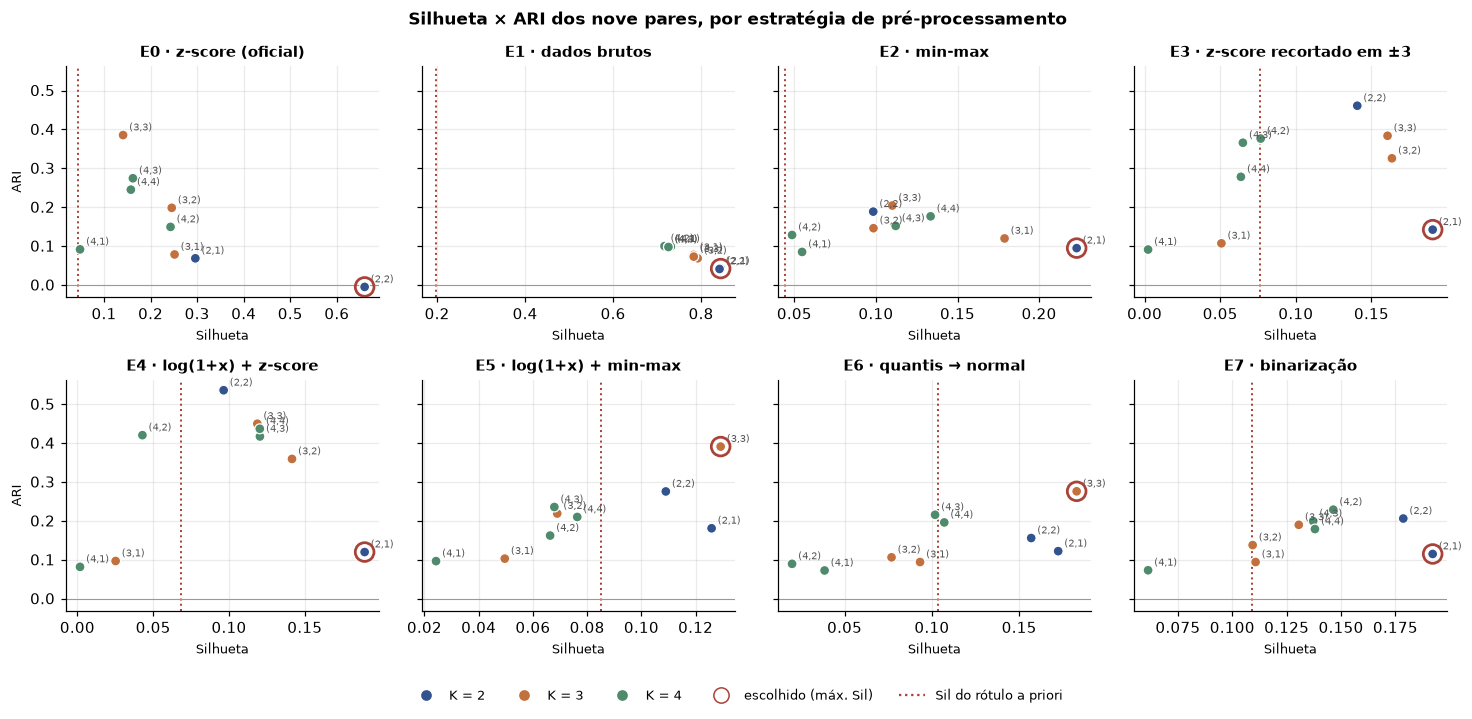

,Sil_do_rotulo,Sil_minima_da_grade,Sil_maxima_da_grade,pares_com_Sil_maior_que_o_rotulo
estrategia,,,,
E0 · z-score (oficial),0.0440,0.0484,0.6596,9 de 9
E1 · dados brutos,0.1975,0.7167,0.8444,9 de 9
E2 · min-max,0.0441,0.0486,0.2230,9 de 9
E3 · z-score recortado em ±3,0.0762,0.0023,0.1904,5 de 9
E4 · log(1+x) + z-score,0.0683,0.0017,0.1895,6 de 9
E5 · log(1+x) + min-max,0.0850,0.0243,0.1292,3 de 9
E6 · quantis → normal,0.1036,0.0199,0.1829,4 de 9
E7 · binarização,0.1091,0.0613,0.1921,8 de 9


In [12]:
ref_rotulo = pd.DataFrame({
    "estrategia": [NOMES[c] for c in DADOS],
    "Sil_do_rotulo": [silhueta_rotulo[c] for c in DADOS],
    "Sil_minima_da_grade": [grade.loc[grade.estrategia == c, "Silhueta"].min() for c in DADOS],
    "Sil_maxima_da_grade": [grade.loc[grade.estrategia == c, "Silhueta"].max() for c in DADOS],
    "pares_com_Sil_maior_que_o_rotulo": [
        f"{int((grade.loc[grade.estrategia == c, 'Silhueta'] > silhueta_rotulo[c]).sum())} de 9"
        for c in DADOS],
}).set_index("estrategia")

fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.4), sharey=True)
for ax, cod in zip(axes.ravel(), DADOS):
    g = grade[grade["estrategia"] == cod]
    sel = g.loc[g["Silhueta"].idxmax()]
    ax.scatter(g["Silhueta"], g["ARI"], s=42, c=[K_COLORS[k] for k in g["K"]], zorder=3,
               edgecolors="white", linewidths=0.8)
    ax.scatter([sel.Silhueta], [sel.ARI], s=150, facecolors="none", edgecolors=C_ALERT,
               linewidths=1.8, zorder=4)
    for r in g.itertuples():
        ax.annotate(f"({r.K},{r.H})", (r.Silhueta, r.ARI), textcoords="offset points",
                    xytext=(4, 3), fontsize=6.5, color="#555555")
    ax.axvline(silhueta_rotulo[cod], color=C_ALERT, linestyle=":", linewidth=1.3)
    ax.axhline(0, color="#999999", linewidth=0.7)
    ax.set_title(NOMES[cod], fontsize=9.5)
    ax.set_xlabel("Silhueta", fontsize=8.5)
for ax in axes[:, 0]:
    ax.set_ylabel("ARI", fontsize=8.5)
fig.legend(handles=[Line2D([], [], marker="o", linestyle="", color=K_COLORS[k], label=f"K = {k}")
                    for k in K_VALUES]
                   + [Line2D([], [], marker="o", linestyle="", markerfacecolor="none",
                             markeredgecolor=C_ALERT, markersize=10, label="escolhido (máx. Sil)"),
                      Line2D([], [], color=C_ALERT, linestyle=":", label="Sil do rótulo a priori")],
           loc="lower center", ncol=5, fontsize=8.5, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Silhueta × ARI dos nove pares, por estratégia de pré-processamento",
             fontweight="bold", fontsize=11)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.savefig(OUT_DIR / "silhueta_vs_ari_por_estrategia.png", dpi=150, bbox_inches="tight")
plt.show()

ref_rotulo.round(4)

> **Leitura.** Em todos os oito espaços a silhueta do rótulo verdadeiro é baixa, entre 0,044 e
> 0,197. Em E0, E1 e E2 ela é inferior à de **todos** os nove pares, e em E7 à de oito. O maior
> valor (0,197, nos dados brutos) é menos de um terço da silhueta do pior par daquele espaço
> (0,717).
>
> Isso generaliza o achado da Seção 6.1 do notebook principal: **a distinção spam / não-spam
> não forma grupos compactos e bem separados em nenhuma das representações avaliadas**. Como a
> silhueta mede exatamente compacidade e separação, ela não tem como privilegiar essa partição,
> qualquer que seja o pré-processamento.
>
> Os painéis mostram ainda o padrão do espaço oficial (E0): o par escolhido é um ponto isolado
> à direita, com ARI nulo. A silhueta alta não vem de uma estrutura que organize a base inteira,
> e sim de um grupo pequeno e muito afastado do restante.

---
## 7. Estabilidade do protocolo oficial frente às sementes

O notebook principal mostrou (Seção 4.2) que, em alguns pares, apenas ~1% das execuções alcança
o melhor mínimo encontrado. Se a probabilidade de uma execução alcançá-lo é $p$, a
probabilidade de pelo menos uma de 100 execuções independentes alcançá-lo é $1-(1-p)^{100}$,
que para $p = 0{,}01$ é apenas $\approx 63\%$. O melhor de 100 pode, portanto, não ser o mesmo
se o protocolo for repetido com outras sementes.

Repetimos o protocolo oficial (E0) com **dois blocos adicionais de 100 sementes** por par e
comparamos as três soluções retidas.

In [13]:
estab = []
for (K, H) in PARES:
    oficial = R[("E0", K, H, 0)]
    W_300 = np.concatenate([R[("E0", K, H, b)]["todos_W"] for b in BLOCOS_SEMENTES])
    melhor_300 = W_300.min()
    p_hat = np.mean(W_300 <= melhor_300 * (1 + TOL))
    linha = {"K": K, "H": H, "W*_oficial": oficial["W_melhor"]}
    for b in BLOCOS_SEMENTES[1:]:
        s = R[("E0", K, H, b)]
        linha[f"W*_bloco_+{b}"] = s["W_melhor"]
        linha[f"ARI_particao_vs_oficial_+{b}"] = adjusted_rand_score(oficial["u"], s["u"])
    linha["oficial_e_o_melhor_de_300"] = bool(oficial["W_melhor"] <= melhor_300 * (1 + TOL))
    linha["p_hat_(300_execucoes)"] = p_hat
    linha["P(melhor_de_100_acha_o_melhor)"] = 1 - (1 - p_hat) ** N_INIT
    estab.append(linha)
estab = pd.DataFrame(estab)

print("Par selecionado pela silhueta em cada bloco de sementes:")
for b in BLOCOS_SEMENTES:
    sil_b = {(K, H): R[("E0", K, H, b)]["Silhueta"] for (K, H) in PARES}
    K_b, H_b = max(sil_b, key=sil_b.get)
    u_b = R[("E0", K_b, H_b, b)]["u"]
    print(f"  bloco +{b:>6}: (K*,H*) = ({K_b},{H_b})  Sil = {sil_b[(K_b, H_b)]:.4f}  "
          f"ARI = {adjusted_rand_score(y, u_b):+.4f}  "
          f"ARI com a particao oficial = {adjusted_rand_score(u_oficial, u_b):.4f}")

estab.round(4)

Par selecionado pela silhueta em cada bloco de sementes:
  bloco +     0: (K*,H*) = (2,2)  Sil = 0.6596  ARI = -0.0049  ARI com a particao oficial = 1.0000
  bloco + 10000: (K*,H*) = (2,2)  Sil = 0.6596  ARI = -0.0049  ARI com a particao oficial = 1.0000
  bloco + 20000: (K*,H*) = (2,2)  Sil = 0.6596  ARI = -0.0049  ARI com a particao oficial = 1.0000


,K,H,W*_oficial,W*_bloco_+10000,ARI_particao_vs_oficial_+10000,W*_bloco_+20000,ARI_particao_vs_oficial_+20000,oficial_e_o_melhor_de_300,p_hat_(300_execucoes),P(melhor_de_100_acha_o_melhor)
0,2,1,256513.7482,256513.7482,1.000,256513.7482,1.0000,True,1.0000,1.0000
1,2,2,244486.6983,244486.6983,1.000,244486.6983,1.0000,True,0.0500,0.9941
2,3,1,254414.0129,254414.0129,1.000,254414.0129,1.0000,True,1.0000,1.0000
3,3,2,239373.6577,239373.6577,1.000,239373.6577,1.0000,True,0.0200,0.8674
4,3,3,234585.8664,234585.8664,1.000,234585.8664,1.0000,True,0.2767,1.0000
5,4,1,253278.6795,253278.6795,1.000,253278.6795,1.0000,True,1.0000,1.0000
6,4,2,233358.7022,233358.7022,1.000,233358.7022,1.0000,True,0.2267,1.0000
7,4,3,228516.4437,228516.4437,1.000,228516.4437,1.0000,True,0.1467,1.0000
8,4,4,227261.6509,227235.1065,0.883,227217.2025,0.9763,False,0.0067,0.4877


> **Leitura.** O par selecionado, $(2,2)$, e a sua partição são **idênticos nos três blocos de
> sementes** (ARI = 1 entre as partições). Nas 300 execuções, 5% alcançam esse mínimo, e a
> probabilidade estimada de um bloco de 100 execuções encontrá-lo é de 99%. A escolha de $K^*$
> e todos os resultados da Questão 1 derivados dela **não dependem das sementes**.
>
> Em oito dos nove pares, o melhor de 100 do protocolo oficial coincide com o melhor de 300
> execuções. Em $(3,2)$ a margem é menor ($\hat{p} = 2\%$, probabilidade de ≈ 87% de um bloco
> encontrar o mínimo), mas os três blocos chegaram ao mesmo resultado. A exceção é $(4,4)$: os
> blocos adicionais encontraram soluções de $W$ ligeiramente menor (227.235 e 227.217, contra
> 227.262 no protocolo oficial, diferença inferior a 0,02%), com partições próximas da oficial
> (ARI de 0,88 e 0,98). Só 2 das 300 execuções alcançam o melhor mínimo conhecido, e a
> probabilidade estimada de um bloco de 100 execuções encontrá-lo é de 49%.
>
> Isso não afeta nenhuma conclusão, pois $(4,4)$ tem silhueta baixa e não disputa a seleção de
> $K^*$. Mas mostra que, em pares com muitos grupos, 100 inicializações aleatórias não garantem
> o ótimo global da função objetivo: o valor reportado para esses pares deve ser lido como o
> **melhor mínimo local encontrado** pelo protocolo do enunciado.

---
## 8. Conclusões

**Outra escolha de pré-processamento "conserta" o resultado? Não.** As oito estratégias
avaliadas, executadas com o protocolo completo do enunciado e as mesmas sementes, levam às
seguintes constatações:

1. **O artefato pode ser removido, mas o rótulo não é recuperado.** As estratégias que atenuam
   a cauda das distribuições eliminam o cluster degenerado de 20 a 34 e-mails, como previa o
   diagnóstico da Seção 3.1. Ainda assim, o par escolhido pela silhueta tem ARI de no máximo
   0,39, e em seis das oito estratégias não passa de 0,14.
2. **Os pares com ARI mais alto existem, mas o critério não os escolhe.** O maior ARI da grade
   (0,536) fica em 6º lugar de 9 no ranking de silhueta da própria estratégia.
3. **O rótulo verdadeiro tem silhueta baixa em todos os espaços** (0,044 a 0,197). A estrutura
   spam / não-spam não é compacta e separada em nenhuma das representações avaliadas, e um
   critério que mede compacidade e separação não pode selecioná-la.
4. **Escolher o pré-processamento pelo ARI seria metodologicamente inválido.** As duas
   estratégias com melhor resultado só se destacam quando se usa o rótulo; *a priori*, as oito
   são igualmente defensáveis, e silhuetas calculadas em espaços diferentes não são comparáveis.

**Robustez do resultado oficial.** O par $(K^*, H^*) = (2,2)$ e a sua partição são reproduzidos
exatamente e são idênticos em três blocos independentes de 100 sementes. A única instabilidade
encontrada, no par $(4,4)$, não interfere na seleção de $K^*$.

**Consequência para o trabalho.** O resultado oficial da Questão 1 permanece o do notebook
principal (*z-score*, $(K^*, H^*) = (2,2)$). Este notebook documenta que a partição degenerada e
o ARI nulo não resultam de uma escolha arbitrária de pré-processamento que outra escolha
corrigiria. Eles refletem uma propriedade da base Spambase sob o critério de seleção pedido:
**a silhueta mede separação geométrica, e a distinção spam / não-spam não é geometricamente
separada nesta base.**

---
## Exportação dos resultados

In [14]:
grade.to_csv(OUT_DIR / "grade_completa.csv", index=False)
sintese.to_csv(OUT_DIR / "sintese_por_estrategia.csv")
ref_rotulo.to_csv(OUT_DIR / "silhueta_do_rotulo_por_estrategia.csv")
diag_prev.to_csv(OUT_DIR / "concentracao_dispersao.csv")
estab.to_csv(OUT_DIR / "estabilidade_sementes.csv", index=False)

print("Arquivos gravados em", OUT_DIR.relative_to(DATA_DIR))
for caminho in sorted(OUT_DIR.iterdir()):
    print("  -", caminho.name)

Arquivos gravados em q1/results/estrategias
  - ari_escolhido_vs_melhor.png
  - concentracao_dispersao.csv
  - concentracao_dispersao.png
  - estabilidade_sementes.csv
  - grade_completa.csv
  - silhueta_do_rotulo_por_estrategia.csv
  - silhueta_vs_ari_por_estrategia.png
  - sintese_por_estrategia.csv
